In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Customer Churn.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing null value with 0 as tenure is 0 and no total charges are recorded

In [4]:
 data["TotalCharges"] = data["TotalCharges"].replace(" ","0")
 data["TotalCharges"] = data["TotalCharges"].astype(float)

In [6]:
data.duplicated().sum()

0

In [7]:
def conv(value):
    if value == 1:
        return "YES"
    else:
        return "NO"

data["SeniorCitizen"] = data["SeniorCitizen"].apply(conv)

# CONVERTED 0 AND 1 OF SENIOR CITIZEN TO YES OR NO TO MAKE IT EASIER TO UNDERSTAND

In [8]:
a = data["Churn"].value_counts()

In [9]:
ind = a.index
val = a.values

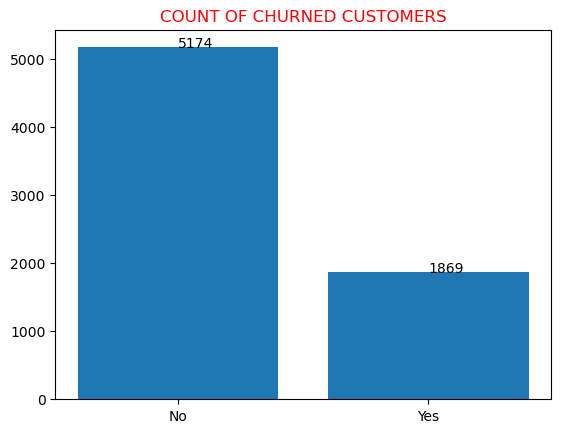

In [10]:
plt.bar(x = ind , height = val)
for i in range(0,len(ind)):
    plt.annotate(xy = (i,val[i]) , text = val[i])
plt.title("COUNT OF CHURNED CUSTOMERS" , color = "red")
plt.show()

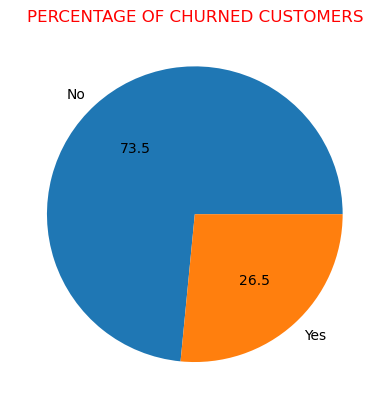

In [11]:
plt.pie(x = val , labels = ind , autopct = "%1.1f")
plt.title("PERCENTAGE OF CHURNED CUSTOMERS" , color = "red")
plt.show()

In [12]:
# from the above pie chart we can conclude that 26.5% of our customer has been churned out

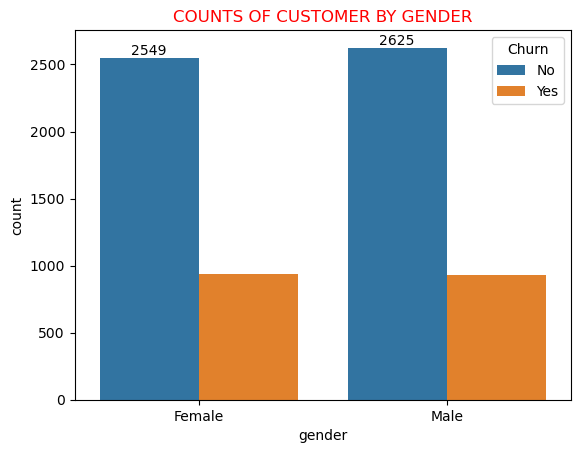

In [20]:
ax = sns.countplot(x = "gender" , data = data , hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("COUNTS OF CUSTOMER BY GENDER" , color = "red")
plt.show()

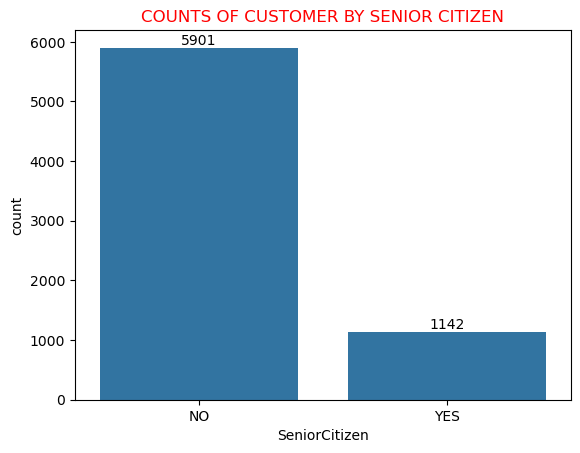

In [21]:
ax = sns.countplot(x = "SeniorCitizen" , data = data )
ax.bar_label(ax.containers[0])
plt.title("COUNTS OF CUSTOMER BY SENIOR CITIZEN" , color = "red")
plt.show()

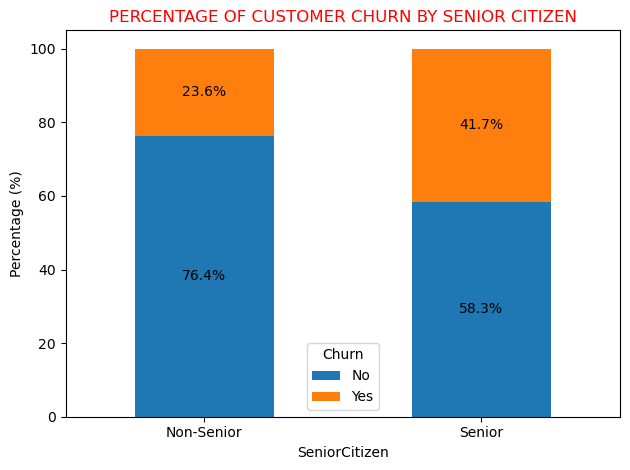

In [25]:

# Convert to percentage stacked data
stack_data = pd.crosstab(data["SeniorCitizen"], data["Churn"], normalize="index") * 100

# Plot stacked bar chart
ax = stack_data.plot(kind="bar", stacked=True)

# Add percentage labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.title("PERCENTAGE OF CUSTOMER CHURN BY SENIOR CITIZEN", color="red")
plt.xlabel("SeniorCitizen")
plt.ylabel("Percentage (%)")

# Optional: better labels instead of 0/1
plt.xticks(ticks=[0, 1], labels=["Non-Senior", "Senior"], rotation=0)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#comparitive a greater percentage in senior citizen has been churned

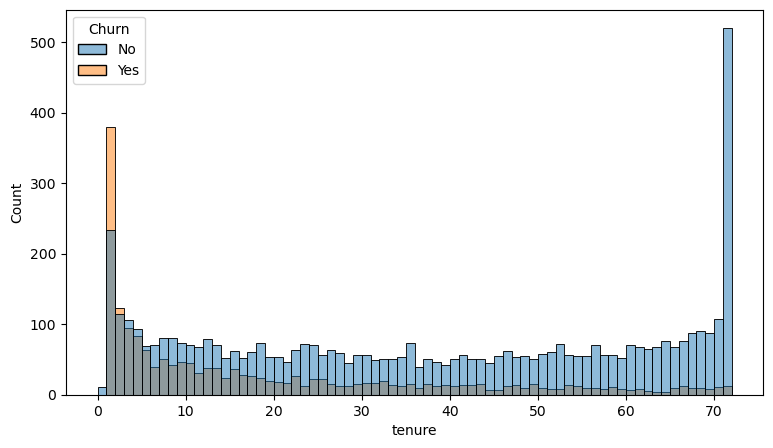

In [33]:
plt.figure(figsize = (9,5))
sns.histplot(x = "tenure" , data = data, bins = 72, hue = "Churn")
plt.show()

#people who had used our service for longer time have stayed and people who had used our service for 1 or 2  month had churned

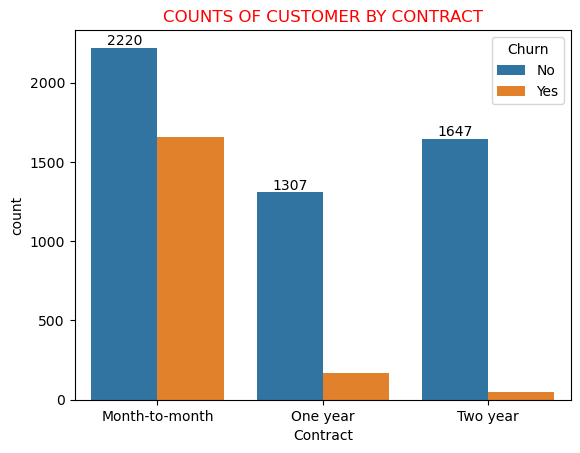

In [40]:
ax = sns.countplot(x = "Contract" , data = data , hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("COUNTS OF CUSTOMER BY CONTRACT" , color = "red")
plt.show()

#people who have month to month contract has likely to churn than those who have 1 or 2 year contract

In [41]:
data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

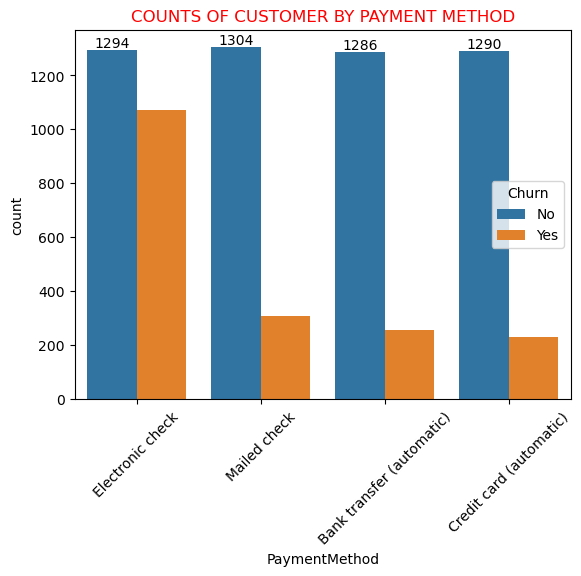

In [56]:
ax = sns.countplot(x = "PaymentMethod" , data = data, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("COUNTS OF CUSTOMER BY PAYMENT METHOD" , color = "red")
plt.xticks(rotation = 45, ha = "center")
plt.show()

#CUSTOMER IS LIKELY TO CHURN WHEN HE IS USING ELECTRONIC CHECK AS A PAYMENT METHOD

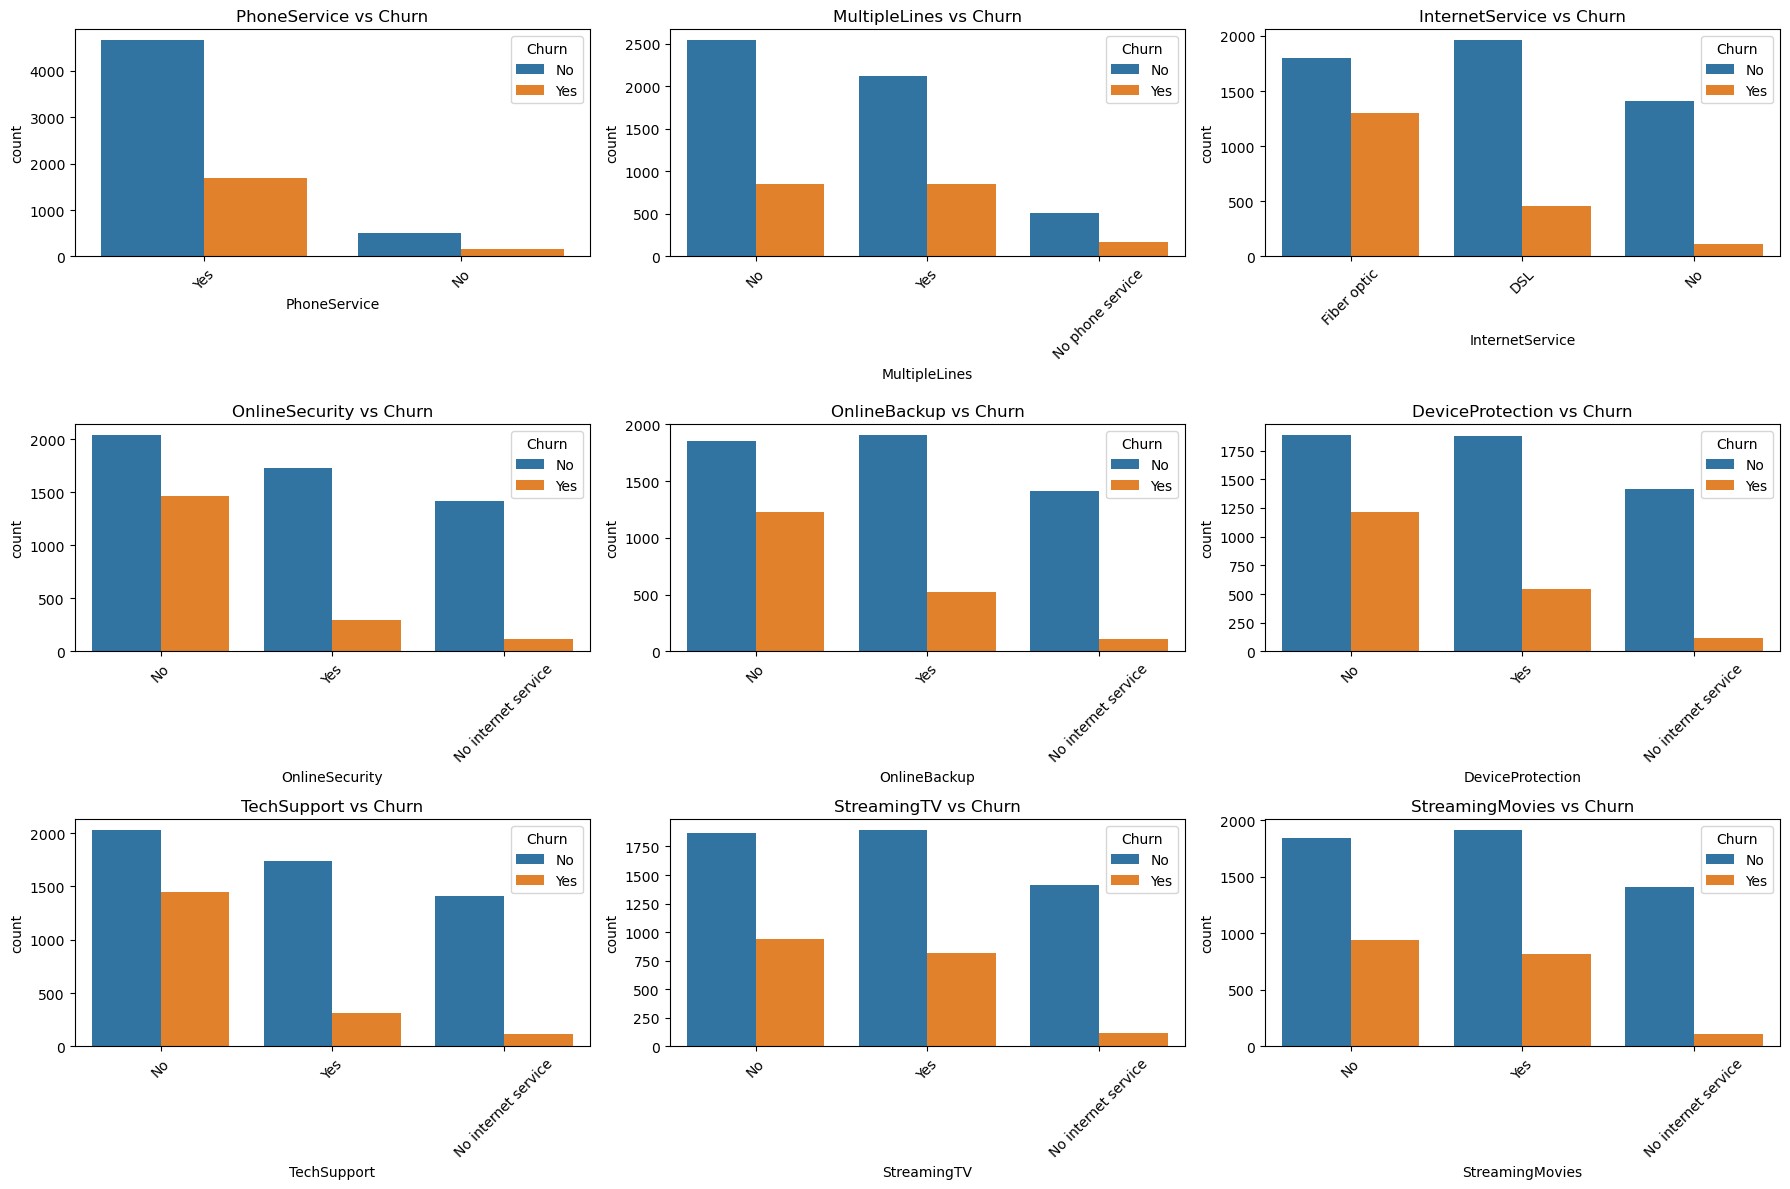

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(
        x=data[col],
        hue="Churn",
        data=data,
        order=data[col].value_counts().index, # No, Yes
    )
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Fiber Optic Risk: Fiber optic customers exhibit a disproportionately high churn rate compared to DSL or no-internet users, marking them as the highest-risk segment.
#Retention Through Security/Support: The presence of Online Security and Tech Support significantly lowers churn. Customers without these services are much more likely to leave.
#Utility vs. Entertainment: Basic utility add-ons (Security, Backup, Device Protection) appear to be stronger retention "anchors" than entertainment add-ons (Streaming TV/Movies).
#Low-Engagement Stability: The "No Internet Service" group is the most stable, showing the lowest churn across all categories.
#Neutral Factors: Phone service and Multiple Lines have a negligible impact on the churn-to-retention ratio.